# Sprint 1 EDA — LaSDPC IoT Dataset (Temperature & RH)

Dataset characterisation restricted to **temperature + relative humidity only**
(CO₂/light excluded — interface-only per project scope, KB §7/§17.3).

Source: `datasets/iot-dataset/Dataset_slice.csv`

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATASET_PATH = Path("../datasets/iot-dataset/Dataset_slice.csv")

DEVICE_TYPE_TEMPERATURE = 1
DEVICE_TYPE_HUMIDITY = 2
DEVICE_TYPE_LABELS = {
    1: "temperature",
    2: "relative_humidity",
    10: "energy_co2_proxy",
    11: "light_intensity",
}
MODEL_DEVICE_TYPES = (DEVICE_TYPE_TEMPERATURE, DEVICE_TYPE_HUMIDITY)
RH_HIGH_THRESHOLD = 75.0


## 1. Load raw data

In [4]:
df_raw = pd.read_csv(DATASET_PATH)
df_raw["date_time"] = pd.to_datetime(df_raw["date_time"], format="mixed", utc=False)
df_raw["sensor_value"] = pd.to_numeric(df_raw["sensor_value"], errors="coerce")
df_raw["device_type_label"] = df_raw["id_device_type"].map(DEVICE_TYPE_LABELS)

df_raw.head()

,id,id_device,id_enviroment,id_device_type,date_time,sensor_value,device_type_label
0,10773735,15,1,2,2026-01-16 19:41:36.746000-03:00,63.4,relative_humidity
1,10773736,86782,1,10,2026-01-16 19:41:36.804000-03:00,0.0,energy_co2_proxy
2,10773752,6,3,1,2026-01-16 19:41:54.435000-03:00,17.5,temperature
3,10773753,1,1,10,2026-01-16 19:41:55.238000-03:00,0.0,energy_co2_proxy
4,10773754,23,1,11,2026-01-16 19:41:56.548000-03:00,0.0,light_intensity


## 2. Restrict to temperature + RH, drop missing values

Per project scope: only temperature + RH are model inputs. CO₂ and light are excluded here.

In [6]:
df_temp_rh = df_raw[df_raw["id_device_type"].isin(MODEL_DEVICE_TYPES)].copy()

n_before = len(df_temp_rh)
df_clean = df_temp_rh.dropna(subset=["sensor_value"])
n_dropped = n_before - len(df_clean)

print(f"Rows before cleaning: {n_before}")
print(f"Rows dropped (missing sensor_value): {n_dropped}")
print(f"Rows after cleaning: {len(df_clean)}")


Rows before cleaning: 109083
Rows dropped (missing sensor_value): 2
Rows after cleaning: 109081


## 3. Data quality report

In [7]:
span = df_raw["date_time"].max() - df_raw["date_time"].min()
quality = {
    "total_rows_raw": len(df_raw),
    "total_rows_temp_rh": len(df_clean),
    "rows_dropped_missing_value": n_dropped,
    "date_range_start": str(df_raw["date_time"].min()),
    "date_range_end": str(df_raw["date_time"].max()),
    "date_range_span": str(span),
    "n_environments": df_raw["id_enviroment"].nunique(),
    "n_devices": df_raw["id_device"].nunique(),
    "device_types_present": sorted(df_raw["id_device_type"].unique().tolist()),
}
quality


{'total_rows_raw': 182809,
 'total_rows_temp_rh': 109081,
 'rows_dropped_missing_value': 2,
 'date_range_start': '2026-01-16 19:41:36.746000-03:00',
 'date_range_end': '2026-01-19 07:24:23.591000-03:00',
 'date_range_span': '2 days 11:42:46.845000',
 'n_environments': 4,
 'n_devices': 11,
 'device_types_present': [1, 2, 10, 11]}

## 4. Per-zone profile (temperature + RH)

In [8]:
profile = (
    df_clean.groupby(["id_enviroment", "device_type_label"])["sensor_value"]
    .agg(["count", "min", "mean", "max", "std"])
    .reset_index()
    .sort_values(["id_enviroment", "device_type_label"])
    .reset_index(drop=True)
)
profile


,id_enviroment,device_type_label,count,min,mean,max,std
0,1,relative_humidity,33233,50.6,63.882746,80.9,4.707272
1,1,temperature,26897,22.6,25.117258,26.5,0.761517
2,2,relative_humidity,8360,65.5,76.622751,86.7,5.415688
3,2,temperature,7630,21.5,21.948283,22.4,0.173017
4,3,relative_humidity,9851,49.7,58.413430,64.4,1.911582
5,3,temperature,6652,15.0,17.158388,17.9,0.548770
6,4,relative_humidity,9829,52.3,73.774239,86.5,7.075839
7,4,temperature,6629,23.0,25.358350,27.7,1.264445


## 5. Zone coverage — which zones have both temperature and RH?

This project requires ≥2 zones with both channels.

In [9]:
coverage = pd.crosstab(df_clean["id_enviroment"], df_clean["device_type_label"])
for col in ("temperature", "relative_humidity"):
    if col not in coverage.columns:
        coverage[col] = 0
coverage["has_temp_and_rh"] = (coverage["temperature"] > 0) & (coverage["relative_humidity"] > 0)
coverage


device_type_label,relative_humidity,temperature,has_temp_and_rh
id_enviroment,,,
1,33233,26897,True
2,8360,7630,True
3,9851,6652,True
4,9829,6629,True


## 6. High-humidity episodes (>75% RH)

Candidate active-learning query moments under the MVP's uncertainty rule.

In [10]:
rh = df_clean[df_clean["id_device_type"] == DEVICE_TYPE_HUMIDITY]
flagged = rh[rh["sensor_value"] > RH_HIGH_THRESHOLD]
high_rh = (
    flagged.groupby("id_enviroment")["sensor_value"]
    .agg(["count", "mean", "max"])
    .rename(columns={"count": "n_readings_above_threshold"})
)
high_rh


,n_readings_above_threshold,mean,max
id_enviroment,,,
1,429,76.411888,80.9
2,4983,80.351194,86.7
4,5389,79.240842,86.5


## 7. Time series by zone

Each line is one physical device, to avoid connecting readings across different sensors in the same zone.

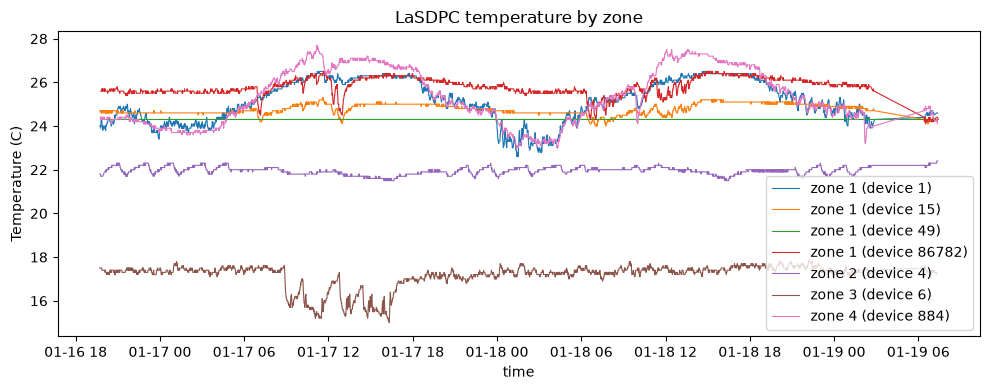

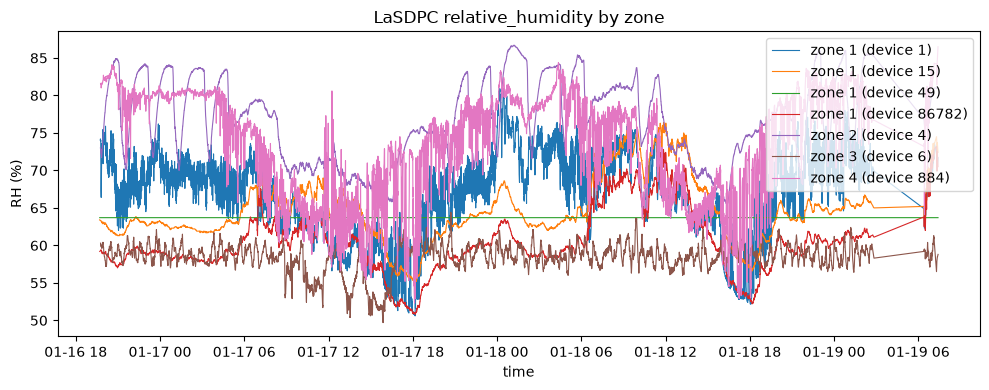

In [11]:
for device_type_label, ylabel in (("temperature", "Temperature (C)"), ("relative_humidity", "RH (%)")):
    subset = df_clean[df_clean["device_type_label"] == device_type_label]
    if subset.empty:
        continue
    fig, ax = plt.subplots(figsize=(10, 4))
    for (zone, device), group in subset.groupby(["id_enviroment", "id_device"]):
        group = group.sort_values("date_time")
        ax.plot(group["date_time"], group["sensor_value"], label=f"zone {zone} (device {device})", linewidth=0.8)
    ax.set_xlabel("time")
    ax.set_ylabel(ylabel)
    ax.set_title(f"LaSDPC {device_type_label} by zone")
    ax.legend()
    fig.tight_layout()
    plt.show()


## Summary

- Raw: 182,809 rows → 109,081 after restricting to T+RH (2 dropped for missing values).
- Data span ≈2.5 days, all 4 zones have both temperature and RH coverage.
- Zones 2 and 4 show the most high-RH episodes (>75%) — prime active-learning trigger candidates.
- Zone 3 is coolest/driest and never crosses the RH threshold.
